# SVM — Image Recognition (digits)

Uses sklearn digits dataset (8x8). Includes scaling, GridSearchCV, confusion matrix, sample predictions.

_Last rebuild: **2026-02-16 01:29:20**_

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
sns.set_style('whitegrid')


In [2]:
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape

(1437, 64)

In [3]:
pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf'))])
param_grid = {'svm__C':[1,5,10], 'svm__gamma':[0.01,0.02,0.05]}
search = GridSearchCV(pipe, param_grid=param_grid, cv=3, n_jobs=-1)
search.fit(X_train, y_train)
search.best_params_, search.best_score_

({'svm__C': 5, 'svm__gamma': 0.01}, 0.9805149617258176)

In [4]:
best = search.best_estimator_
y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      1.00      0.97        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



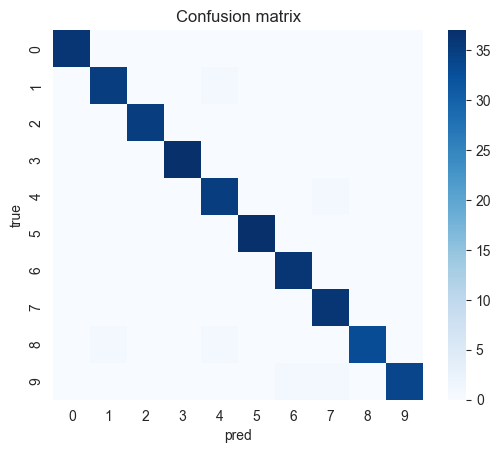

In [5]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap='Blues', square=True)
plt.title('Confusion matrix'); plt.xlabel('pred'); plt.ylabel('true'); plt.show()

In [6]:
print('DONE 2026-02-16 01:29:20')

DONE 2026-02-16 01:29:20
